# Land Type Classification using Sentinel-2 Satellite Images
### **Simple CNN**
***

#### Imports:

In [1]:
import cv2
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import tensorflow as tf

from tensorflow.python.platform.build_info import build_info
from tensorflow.config.experimental import list_physical_devices, VirtualDeviceConfiguration, set_virtual_device_configuration #type:ignore

from tensorflow.keras.regularizers import l2 #type:ignore
from tensorflow.keras.optimizers import Adam, RMSprop, SGD #type:ignore
from tensorflow.keras.models import Sequential #type:ignore
from tensorflow.keras.losses import CategoricalCrossentropy # type: ignore
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint #type:ignore
from tensorflow.keras.preprocessing.image import ImageDataGenerator #type:ignore
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout #type:ignore
from tensorflow.keras.layers import BatchNormalization, GlobalAveragePooling2D, LeakyReLU, AveragePooling2D #type:ignore
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, confusion_matrix
from tensorflow.keras.models import load_model #type:ignore

from pathlib import Path
import os
import shutil
import random

#### Parameters and Settings:

In [2]:
params = { 
    'filters': 64,
    'conv_layers': 3,
    'dense_units': 128, 
    'dropout': 0.30, 
    'batch_norm': True, 
    'optimizer': "adam", 
    'lr': 1e-3, 
    'flattening_layers': "GAP2D",
    'random_state': 42
}

#### Set seeds:

In [3]:
random.seed(params["random_state"])
np.random.seed(params["random_state"])
tf.random.set_seed(params["random_state"])

***
### GPU Setup `tensorflow`
 1. Check if GPU register
 2. limiting VRAM (CUDA will allocate whole VRAM by Default)

In [4]:
print(tf.__version__)

GPU_RUN: bool = False

if list_physical_devices("GPU") != []:
    GPU_RUN = True
            
def limit_gpu_vram(vram = None):
    if vram == None:
        print("[!] Maximum GPU memory allowed")
        return
    
    gpus = list_physical_devices("GPU")
    try:
        set_virtual_device_configuration( gpus[0], [VirtualDeviceConfiguration(memory_limit= vram * 1024)] )
        print(f"[/] Limited GPU memory to {vram} GB.")
    except RuntimeError as e:
        print(e)

if GPU_RUN:
    print(tf.config.list_physical_devices("GPU"))

    print("-"*19)

    print("CUDA:", build_info["cuda_version"]) #type:ignore
    print("cuDNN:", build_info["cudnn_version"]) #type:ignore

    print("-"*19)
    
    limit_gpu_vram()

2.17.1


### Had to re-define `CategoricalFocalLoss` as it was missing in this old version of tensorflow
 - should have the same functionanlity

In [5]:
from tensorflow.keras.losses import Loss #type:ignore
from tensorflow.keras import backend as K #type:ignore

categorical_focal = None
if GPU_RUN:
    print("[!] Using custom GPU focal loss")
    class CategoricalFocalLoss(Loss):
        def __init__(self, gamma=2.0, alpha=0.25, from_logits=False, reduction=tf.keras.losses.Reduction.AUTO, name="categorical_focal_loss"): #type:ignore
            super().__init__(reduction=reduction, name=name)
            self.gamma = float(gamma)
            self.alpha = float(alpha)
            self.from_logits = from_logits

        def call(self, y_true, y_pred):
            if self.from_logits:
                y_pred = tf.nn.softmax(y_pred, axis=-1)
            eps = K.epsilon()
            y_pred = K.clip(y_pred, eps, 1.0 - eps)

            cross_entropy = -y_true * K.log(y_pred)

            p_t = K.sum(y_true * y_pred, axis=-1, keepdims=True)
            focal_factor = K.pow(1.0 - p_t, self.gamma)
            
            loss = self.alpha * focal_factor * cross_entropy
            loss = K.sum(loss, axis=-1)
            return K.mean(loss)

        def get_config(self):
            return {"gamma": self.gamma, "alpha": self.alpha, "from_logits": self.from_logits}
        
    categorical_focal = CategoricalFocalLoss()
else:
    print("[!] Using built-in CPU focal loss")
    from tensorflow.keras.losses import CategoricalFocalCrossentropy #type:ignore
    categorical_focal = CategoricalFocalCrossentropy()
    
print(categorical_focal)

[!] Using built-in CPU focal loss
<LossFunctionWrapper(<function categorical_focal_crossentropy at 0x0000029226E2F1A0>, kwargs={'alpha': 0.25, 'gamma': 2.0, 'from_logits': False, 'label_smoothing': 0.0, 'axis': -1})>


#### Split data into folders

In [6]:
project_root = Path(os.getcwd())

dataset_root = project_root / "Dataset"
original_folder = dataset_root / "EuroSAT_RGB"
base_folder = dataset_root / "EuroSAT_RGB_split"

checkpoints_dir = project_root


print("Project Root:       ",project_root)
print("Dataset Root:       ",dataset_root)
print("Original Root:      ",original_folder)
print("Base Folder:        ",base_folder)
print("Checkpoints Folder: ",checkpoints_dir)

Project Root:        c:\Users\S1NdBAD\Desktop\DEPI Final Project
Dataset Root:        c:\Users\S1NdBAD\Desktop\DEPI Final Project\Dataset
Original Root:       c:\Users\S1NdBAD\Desktop\DEPI Final Project\Dataset\EuroSAT_RGB
Base Folder:         c:\Users\S1NdBAD\Desktop\DEPI Final Project\Dataset\EuroSAT_RGB_split
Checkpoints Folder:  c:\Users\S1NdBAD\Desktop\DEPI Final Project


In [7]:
def split_data():
    train_ratio = 0.7
    val_ratio = 0.15
    random_state = 42
    random.seed(random_state)

    for split in ["train", "validate", "test"]:
        os.makedirs(os.path.join(base_folder, split), exist_ok=True)
    
    for class_name in os.listdir(original_folder):
        class_path = os.path.join(original_folder, class_name)
        if not os.path.isdir(class_path):
            continue

        images = [f for f in os.listdir(class_path) if f.lower().endswith((".jpg", ".png", ".tif"))]
        random.shuffle(images)

        n_total = len(images)
        n_train = int(n_total * train_ratio)
        n_val = int(n_total * val_ratio)

        splits = {
            "train": images[:n_train],
            "validate": images[n_train:n_train + n_val],
            "test": images[n_train + n_val:]
        }

        for split_name, split_images in splits.items():
            split_dir = os.path.join(base_folder, split_name, class_name)
            os.makedirs(split_dir, exist_ok=True)

            for img_name in split_images:
                src = os.path.join(class_path, img_name)
                dst = os.path.join(split_dir, img_name)
                shutil.copy(src, dst)

        print(f"{class_name}: {n_total} images split into train/val/test")

In [8]:
#split_data()


#### split_data() Output:
 - AnnualCrop: 3000 images split into train/val/test
 - Forest: 3000 images split into train/val/test
 - HerbaceousVegetation: 3000 images split into train/val/test
 - Highway: 2500 images split into train/val/test
 - Industrial: 2500 images split into train/val/test
 - Pasture: 2000 images split into train/val/test
 - PermanentCrop: 2500 images split into train/val/test
 - Residential: 3000 images split into train/val/test 
 - River: 2500 images split into train/val/test 
 - SeaLake: 3000 images split into train/val/test


In [9]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    base_folder / "train",
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    base_folder / "validate",
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    shuffle=False 
)

test_generator = val_test_datagen.flow_from_directory(
    base_folder / "test",
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    shuffle=False 
)

Found 18900 images belonging to 10 classes.
Found 4050 images belonging to 10 classes.
Found 4050 images belonging to 10 classes.


***
### **Model (**`CNN`**) Training**

In [ ]:
modelcheckpoint = ModelCheckpoint(str(checkpoints_dir / f"sequential_model.h5"), monitor="val_loss", save_best_only=True, verbose=0)
if not GPU_RUN:
    modelcheckpoint = ModelCheckpoint(str(checkpoints_dir / f"sequential_model.keras"), monitor="val_loss", save_best_only=True, verbose=0)

callbacks = [
    modelcheckpoint,
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.33, patience=2, min_lr=1e-6)
]

model = Sequential()
filters = params['filters']
for i in range(params['conv_layers']):
    if i == 0:
        model.add(Conv2D(filters, (3,3), activation='relu',kernel_regularizer=l2(0.001) ,input_shape=(64, 64, 3)))
    else:
        model.add(Conv2D(filters, (3,3), activation='relu'))
    model.add(MaxPooling2D(2,2))
    if params['batch_norm']:
        model.add(BatchNormalization())
    filters *= 2  # Double filters each block
    
if params["flattening_layers"] == "GAP2D":
    model.add(GlobalAveragePooling2D())
    model.add(Dense(params['dense_units'], activation='relu', kernel_regularizer=l2(0.001)))
else:
    model.add(Flatten())
    model.add(Dense(params['dense_units'], activation='relu'))
    
model.add(Dropout(params['dropout']))
model.add(Dense(train_generator.num_classes, activation='softmax'))

if params['optimizer'] == 'adam':
    opt = Adam(learning_rate=params['lr'])
elif params['optimizer'] == 'rmsprop':
    opt = RMSprop(learning_rate=params['lr'])
else:
    opt = SGD(learning_rate=params['lr'], momentum=0.9)
    

model.compile(
    optimizer=opt, 
    loss=categorical_focal,
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

c:\Users\S1NdBAD\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\S1NdBAD\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 63s 103ms/step - accuracy: 0.6230 - loss: 0.2860 - val_accuracy: 0.1272 - val_loss: 1.0146 - learning_rate: 0.0010
Epoch 2/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 51s 86ms/step - accuracy: 0.7275 - loss: 0.1583 - val_accuracy: 0.5440 - val_loss: 0.2635 - learning_rate: 0.0010
Epoch 3/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 52s 88ms/step - accuracy: 0.7716 - loss: 0.1134 - val_accuracy: 0.6993 - val_loss: 0.1317 - learning_rate: 0.0010
Epoch 4/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 51s 87ms/step - accuracy: 0.8110 - loss: 0.0867 - val_accuracy: 0.2995 - val_loss: 1.2027 - learning_rate: 0.0010
Epoch 5/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 52s 89ms/step - accuracy: 0.8286 - loss: 0.0767 - val_accuracy: 0.6284 - val_loss: 0.1951 - learning_rate: 0.0010
Epoch 6/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 55s 94ms/step - accuracy: 0.8848 - loss: 0.0526 - val_accuracy: 0.7711 - val_loss: 0.1205 - learning_rate: 3.3000e-04
Epoch 7/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 59s 99ms/step - accuracy: 0.897

***
#### Load Model

In [11]:
#model = tf.keras.models.load_model("model.h5")

#### print used VRAM

In [12]:
if GPU_RUN:
    gpus = tf.config.list_physical_devices("GPU")
    details = tf.config.experimental.get_memory_info(gpus[0].name[17:])
    
    print(f"[/] GPU: {gpus[0].name}")
    print(f"  Used VRAM: {details["current"] / 1024**2:.2f} MB")
    print(f"  Peak VRAM: {details["peak"] / 1024**2:.2f} MB")
else:
    print("[!] No GPU used")

[!] No GPU used


#### **Model Test**
**Returns:**
 - Test Accuracy
 - Test Loss
 - y Predict

In [13]:
def evaluate_model(model, test_ds, class_names):
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    print(f"\nTest Results:\nAccuracy: {test_acc:.4f} | Loss: {test_loss:.4f}")

    preds = model.predict(test_ds, verbose=1)
    y_pred = np.argmax(preds, axis=1)

    if hasattr(test_ds, 'labels'):
        y_true = test_ds.labels
    else:
        y_true = np.concatenate([np.argmax(y, axis=1) for _, y in test_ds], axis=0)

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

    print('\nClassification Report:\n')
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    return test_acc, test_loss, y_pred


Test Results:
Accuracy: 0.9516 | Loss: 0.0224
127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step


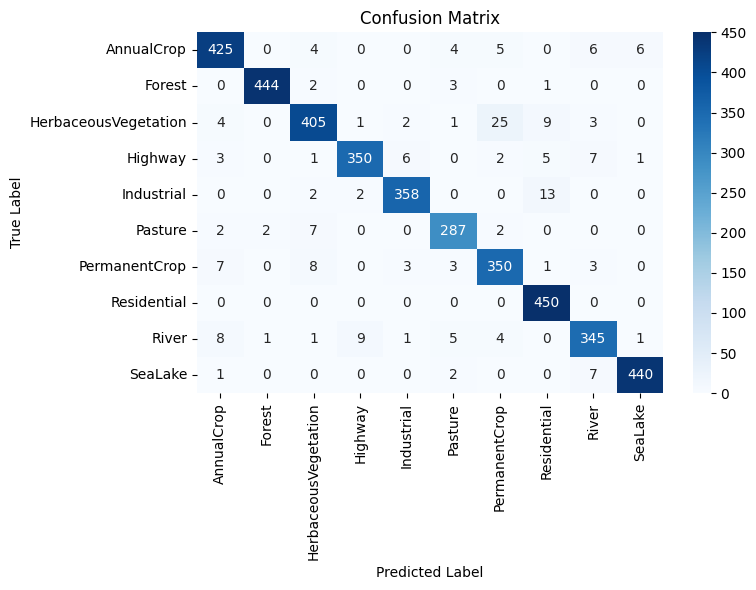


Classification Report:

                      precision    recall  f1-score   support

          AnnualCrop     0.9444    0.9444    0.9444       450
              Forest     0.9933    0.9867    0.9900       450
HerbaceousVegetation     0.9419    0.9000    0.9205       450
             Highway     0.9669    0.9333    0.9498       375
          Industrial     0.9676    0.9547    0.9611       375
             Pasture     0.9410    0.9567    0.9488       300
       PermanentCrop     0.9021    0.9333    0.9174       375
         Residential     0.9395    1.0000    0.9688       450
               River     0.9299    0.9200    0.9249       375
             SeaLake     0.9821    0.9778    0.9800       450

            accuracy                         0.9516      4050
           macro avg     0.9509    0.9507    0.9506      4050
        weighted avg     0.9519    0.9516    0.9515      4050



In [14]:
test_acc, test_loss, y_pred = evaluate_model(model, test_generator, list(test_generator.class_indices.keys()))

***
#### **Plot Training Process**

In [15]:
def plot_training_curves(history, test_acc=0):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    plt.plot(epochs_range, acc, label='Train Acc')
    plt.plot(epochs_range, val_acc, label='Val Acc')
    plt.axhline(y=test_acc, linestyle='--', color='green', label=f'Test Acc: {test_acc:.2f}')
    plt.title('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

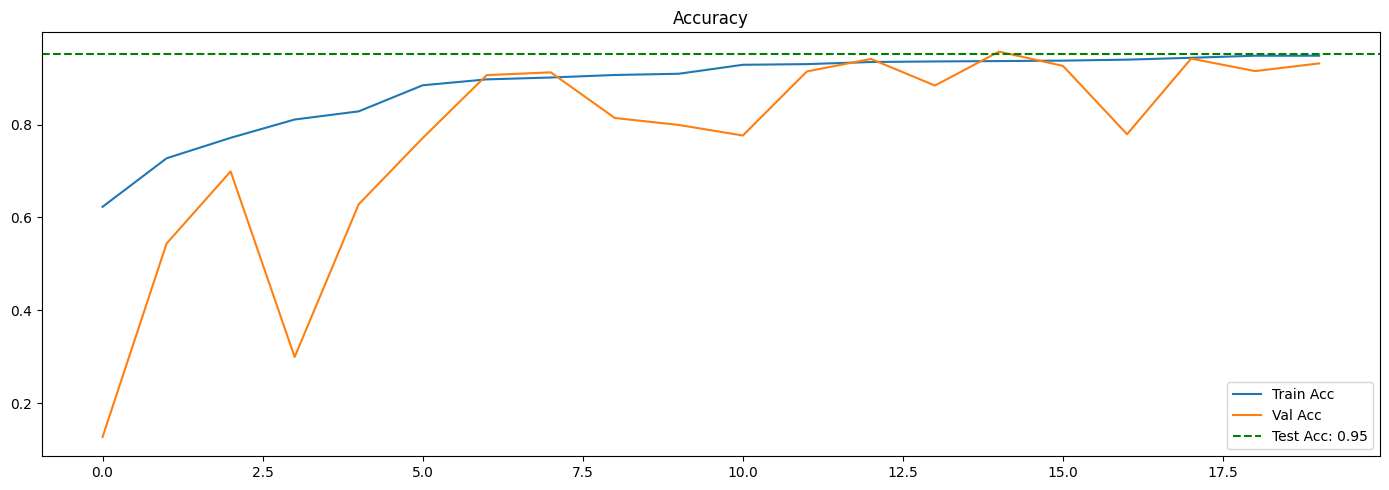

In [16]:
plot_training_curves(history, test_acc=test_acc)

***
#### Pick **Random** Image as test

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


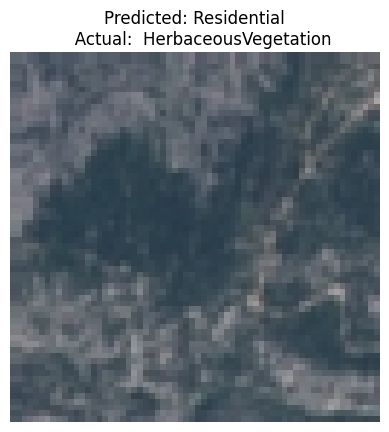

In [17]:
basefolder = dataset_root / "EuroSAT_RGB_split"
img_size = (64, 64)
class_names = list(test_generator.class_indices.keys())

all_image_paths = []

for split_dir in os.listdir(basefolder):
    split_path = os.path.join(basefolder, split_dir)
    if os.path.isdir(split_path):
        for class_dir in os.listdir(split_path):
            class_path = os.path.join(split_path, class_dir)
            if os.path.isdir(class_path):
                for fname in os.listdir(class_path):
                    if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                        full_path = os.path.join(class_path, fname)
                        all_image_paths.append(full_path)


random_image_path = random.choice(all_image_paths)
image_type = random_image_path.split("\\")[-1].split("_")[0]

img = cv2.imread(random_image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) #type: ignore
img_resized = cv2.resize(img, img_size)
img_array = np.expand_dims(img_resized, axis=0) / 255.0  # normalize

pred = model.predict(img_array)
pred_class = class_names[np.argmax(pred)]

plt.imshow(img)
plt.title(f"Predicted: {pred_class}\n   Actual:  {image_type}")
plt.axis('off')
plt.show()